In [1]:
!pip install torchinfo fvcore --quiet

import os, time, random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

from torchinfo import summary
from fvcore.nn import FlopCountAnalysis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
NUM_CLASSES = 100
BATCH_SIZE = 128
EPOCHS = 80
LR = 0.001   # Adam

In [4]:
MEAN = (0.5071, 0.4867, 0.4408)
STD  = (0.2675, 0.2565, 0.2761)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_set = torchvision.datasets.CIFAR100('./data', train=True, download=True, transform=train_transform)
test_set  = torchvision.datasets.CIFAR100('./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 169M/169M [00:24<00:00, 7.00MB/s]


In [14]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),

            # NEW BLOCK (important)
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 100)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

In [15]:
# 1. DEFINE MODEL
model = ImprovedCNN().to(device)   # or your CustomCNN

# 2. DEFINE LOSS
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# 3. DEFINE OPTIMIZER
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.05,
    momentum=0.9,
    weight_decay=5e-4
)

# 4. DEFINE SCHEDULER
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS
)

In [16]:
def train_epoch():
    model.train()

    total, correct, loss_sum = 0, 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        correct += out.argmax(1).eq(y).sum().item()
        total += y.size(0)

    return loss_sum / len(train_loader), 100 * correct / total

In [17]:
def test_epoch():
    model.eval()

    total, correct, loss_sum = 0, 0, 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            loss_sum += loss.item()
            correct += out.argmax(1).eq(y).sum().item()
            total += y.size(0)

    return loss_sum / len(test_loader), 100 * correct / total

In [18]:
warmup_epochs = 5

train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(EPOCHS):

    # 🔥 Warmup (first few epochs)
    if epoch < warmup_epochs:
        lr = 0.01 + (0.04 * epoch / warmup_epochs)   # 0.01 → 0.05
        for g in optimizer.param_groups:
            g['lr'] = lr

    tr_loss, tr_acc = train_epoch()
    te_loss, te_acc = test_epoch()

    # ✅ Scheduler step AFTER epoch
    scheduler.step()

    train_losses.append(tr_loss)
    test_losses.append(te_loss)
    train_accs.append(tr_acc)
    test_accs.append(te_acc)

    print(f"Epoch {epoch+1}: TrainAcc={tr_acc:.2f} TestAcc={te_acc:.2f}")

Epoch 1: TrainAcc=9.03 TestAcc=16.80
Epoch 2: TrainAcc=18.04 TestAcc=23.05
Epoch 3: TrainAcc=24.92 TestAcc=28.65
Epoch 4: TrainAcc=30.76 TestAcc=31.34
Epoch 5: TrainAcc=34.08 TestAcc=34.30
Epoch 6: TrainAcc=38.52 TestAcc=41.81
Epoch 7: TrainAcc=42.41 TestAcc=44.87
Epoch 8: TrainAcc=45.17 TestAcc=47.23
Epoch 9: TrainAcc=47.70 TestAcc=49.05
Epoch 10: TrainAcc=49.52 TestAcc=49.51
Epoch 11: TrainAcc=51.59 TestAcc=52.05
Epoch 12: TrainAcc=53.00 TestAcc=51.82
Epoch 13: TrainAcc=54.36 TestAcc=52.21
Epoch 14: TrainAcc=55.56 TestAcc=54.91
Epoch 15: TrainAcc=56.63 TestAcc=55.16
Epoch 16: TrainAcc=57.63 TestAcc=54.53
Epoch 17: TrainAcc=58.72 TestAcc=57.26
Epoch 18: TrainAcc=59.48 TestAcc=58.44
Epoch 19: TrainAcc=60.65 TestAcc=57.49
Epoch 20: TrainAcc=61.12 TestAcc=58.21
Epoch 21: TrainAcc=61.81 TestAcc=57.97
Epoch 22: TrainAcc=62.41 TestAcc=57.68
Epoch 23: TrainAcc=63.38 TestAcc=56.36
Epoch 24: TrainAcc=64.22 TestAcc=59.10
Epoch 25: TrainAcc=64.46 TestAcc=61.00
Epoch 26: TrainAcc=65.34 TestAcc=62

In [25]:
import torch.nn.utils.prune as prune

def prune_model_safe(model):
    for m in model.modules():

        # Structured pruning for Conv (reduces FLOPs)
        if isinstance(m, nn.Conv2d):
            prune.ln_structured(m, name='weight', amount=0.1, n=2, dim=0)
            prune.remove(m, 'weight')

        # Light pruning for FC
        elif isinstance(m, nn.Linear):
            prune.l1_unstructured(m, name='weight', amount=0.2)
            prune.remove(m, 'weight')

    print("✅ Pruning applied")

In [26]:
print("Before pruning:", test_epoch()[1])

prune_model_safe(model)

print("After pruning:", test_epoch()[1])

Before pruning: 63.62
✅ Pruning applied
After pruning: 61.29


In [27]:
# Lower LR for fine-tuning
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=5e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# Slightly stronger regularization
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print("\n🔁 Fine-tuning after pruning...")

for epoch in range(10):
    tr_loss, tr_acc = train_epoch()
    te_loss, te_acc = test_epoch()

    scheduler.step()

    print(f"[FT Epoch {epoch+1}] Train={tr_acc:.2f} Test={te_acc:.2f}")


🔁 Fine-tuning after pruning...
[FT Epoch 1] Train=78.68 Test=65.69
[FT Epoch 2] Train=80.80 Test=67.95
[FT Epoch 3] Train=82.70 Test=68.37
[FT Epoch 4] Train=84.22 Test=67.51
[FT Epoch 5] Train=86.15 Test=69.83
[FT Epoch 6] Train=88.01 Test=70.85
[FT Epoch 7] Train=89.48 Test=71.06
[FT Epoch 8] Train=90.77 Test=71.94
[FT Epoch 9] Train=91.97 Test=71.84
[FT Epoch 10] Train=92.37 Test=72.06


In [28]:
import copy, os

model_cpu = copy.deepcopy(model).cpu()
model_cpu.eval()

model_q = torch.quantization.quantize_dynamic(
    model_cpu,
    {nn.Linear},
    dtype=torch.qint8
)

torch.save(model_q.state_dict(), "quantized_model.pth")

size_mb = os.path.getsize("quantized_model.pth") / (1024**2)

print("Quantized Model Size (MB):", size_mb)

Quantized Model Size (MB): 18.07387065887451


/tmp/ipykernel_1440/1500645923.py:6: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_q = torch.quantization.quantize_dynamic(


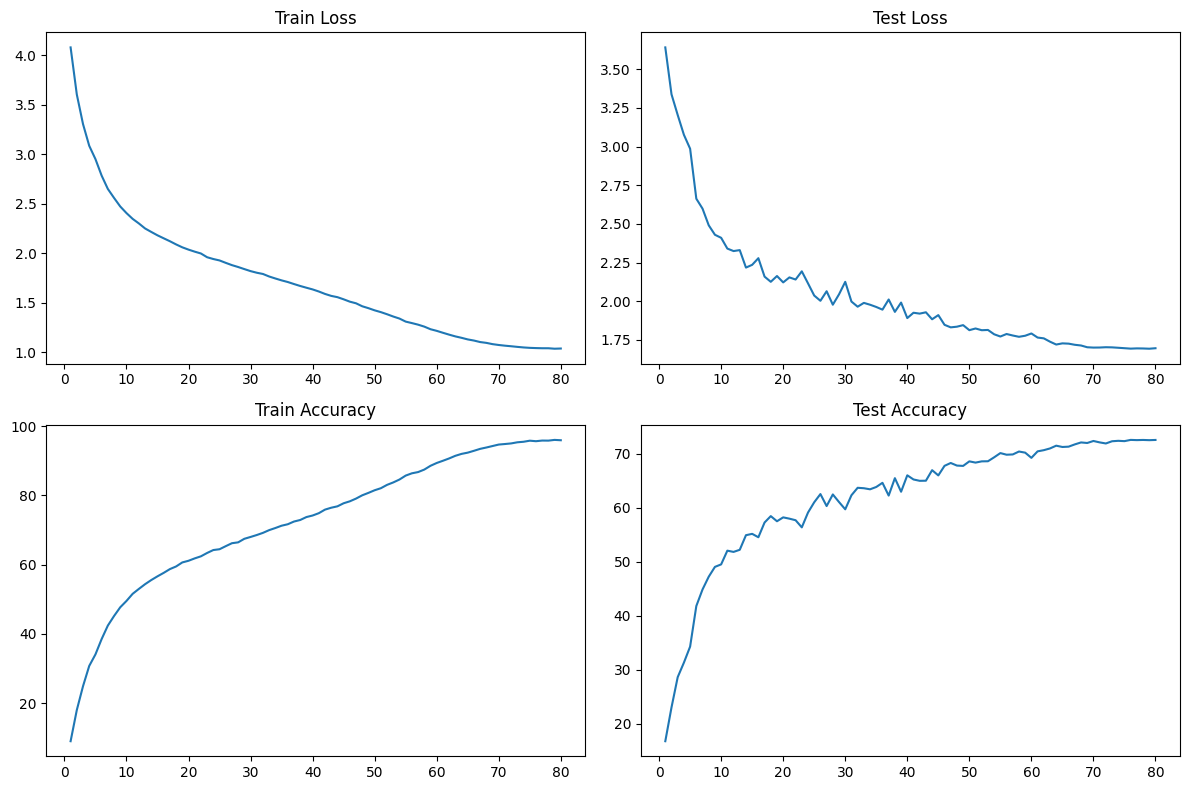

In [29]:
epochs = range(1, EPOCHS+1)

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.plot(epochs, train_losses)
plt.title("Train Loss")

plt.subplot(2,2,2)
plt.plot(epochs, test_losses)
plt.title("Test Loss")

plt.subplot(2,2,3)
plt.plot(epochs, train_accs)
plt.title("Train Accuracy")

plt.subplot(2,2,4)
plt.plot(epochs, test_accs)
plt.title("Test Accuracy")

plt.tight_layout()
plt.show()

In [30]:
model.eval()

dummy = torch.randn(1,3,32,32).to(device)

flops = FlopCountAnalysis(model, dummy).total()
params = sum(p.numel() for p in model.parameters())

print("FLOPs:", flops)
print("Params:", params)

FLOPs: 210037760
Params: 4846244


In [31]:
torch.save(model.state_dict(), "model.pth")

size = os.path.getsize("model.pth")/(1024**2)
print("Model size:", size, "MB")

Model size: 18.517680168151855 MB


In [33]:
# ==============================
# QUANTIZATION + MODEL SIZE
# ==============================

import torch
import os
import copy

# 👉 Move model to CPU (required for quantization)
model_cpu = copy.deepcopy(model).cpu()
model_cpu.eval()

# 👉 Apply dynamic quantization (only Linear layers)
model_quantized = torch.quantization.quantize_dynamic(
    model_cpu,
    {torch.nn.Linear},
    dtype=torch.qint8
)

# 👉 Save quantized model
quant_path = "quantized_model.pth"
torch.save(model_quantized.state_dict(), quant_path)

# 👉 Compute model size
model_size_mb = os.path.getsize(quant_path) / (1024 * 1024)

print("\n" + "="*50)
print("QUANTIZED MODEL RESULTS")
print("="*50)
print(f"Quantized Model Size (MB): {model_size_mb:.2f}")
print("="*50)


QUANTIZED MODEL RESULTS
Quantized Model Size (MB): 18.07


/tmp/ipykernel_1440/3984573724.py:14: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quantized = torch.quantization.quantize_dynamic(


In [36]:
# ==============================
# FINAL EVALUATION METRICS
# ==============================

import os, time
import torch
import numpy as np
from fvcore.nn import FlopCountAnalysis

model.eval()

# ------------------------------
# FULL EVALUATION
# ------------------------------
def evaluate(model, loader):
    model.eval()
    total, correct, top5_correct, loss_sum = 0, 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            loss_sum += loss.item() * x.size(0)

            preds = out.argmax(1)
            correct += preds.eq(y).sum().item()

            top5 = out.topk(5, dim=1).indices
            top5_correct += sum(y[i] in top5[i] for i in range(y.size(0)))

            total += y.size(0)

    return loss_sum/total, 100*correct/total, 100*top5_correct/total


# ------------------------------
# PER-CLASS ACCURACY
# ------------------------------
def per_class_accuracy(model, loader, num_classes=100):
    correct = torch.zeros(num_classes).to(device)   # ✅ move to GPU
    total = torch.zeros(num_classes).to(device)     # ✅ move to GPU

    model.eval()
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            preds = model(x).argmax(1)

            for i in range(len(y)):
                total[y[i]] += 1
                correct[y[i]] += (preds[i] == y[i])

    acc = 100 * correct / total.clamp(min=1)
    return acc.cpu()   # ✅ move back to CPU for printing
# ==============================
# COMPUTE METRICS
# ==============================

train_loss, train_acc, _ = evaluate(model, train_loader)
test_loss, test_acc, top5_acc = evaluate(model, test_loader)

gap_acc = train_acc - test_acc
gap_loss = test_loss - train_loss

# Class accuracy
class_acc = per_class_accuracy(model, test_loader)
lowest_class_acc = class_acc.min().item()
highest_class_acc = class_acc.max().item()

# ------------------------------
# PARAMETERS
# ------------------------------
params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# ------------------------------
# FLOPs (IMPORTANT: use original model, not quantized)
# ------------------------------
dummy = torch.randn(1,3,32,32).to(device)
flops = FlopCountAnalysis(model, dummy).total()

# ------------------------------
# MODEL SIZE
# ------------------------------
torch.save(model.state_dict(), "final_model.pth")
model_size = os.path.getsize("final_model.pth")/(1024**2)

# ------------------------------
# LATENCY
# ------------------------------
def measure_latency(batch_size):
    model.eval()
    dummy = torch.randn(batch_size,3,32,32).to(device)

    # warmup
    for _ in range(10):
        _ = model(dummy)

    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.time()

    for _ in range(50):
        _ = model(dummy)

    if device.type == "cuda":
        torch.cuda.synchronize()

    return (time.time() - start)/50 * 1000

lat_b1 = measure_latency(1)
lat_b32 = measure_latency(32)


# ==============================
# PRINT FINAL RESULTS
# ==============================

print("\n" + "="*60)
print("FINAL EVALUATION METRICS")
print("="*60)

print(f"Best Train Loss          : {train_loss:.4f}")
print(f"Best Test Loss           : {test_loss:.4f}")

print(f"Best Train Accuracy      : {train_acc:.2f}%")
print(f"Best Test Accuracy       : {test_acc:.2f}%")
print(f"Top-5 Test Accuracy      : {top5_acc:.2f}%")

print(f"GAP (Accuracy)           : {gap_acc:.2f}")
print(f"GAP (Loss)               : {gap_loss:.4f}")

print(f"Lowest Class Accuracy    : {lowest_class_acc:.2f}%")
print(f"Highest Class Accuracy   : {highest_class_acc:.2f}%")

print(f"Trainable Parameters     : {params:,}")
print(f"FLOPs                    : {flops:,}")

print(f"Model Size (MB)          : {model_size:.2f}")

print(f"Latency (batch=1) ms     : {lat_b1:.3f}")
print(f"Latency (batch=32) ms    : {lat_b32:.3f}")

print("="*60)


FINAL EVALUATION METRICS
Best Train Loss          : 1.0503
Best Test Loss           : 1.7044
Best Train Accuracy      : 94.55%
Best Test Accuracy       : 72.06%
Top-5 Test Accuracy      : 91.66%
GAP (Accuracy)           : 22.49
GAP (Loss)               : 0.6541
Lowest Class Accuracy    : 44.00%
Highest Class Accuracy   : 95.00%
Trainable Parameters     : 4,846,244
FLOPs                    : 210,037,760
Model Size (MB)          : 18.52
Latency (batch=1) ms     : 1.597
Latency (batch=32) ms    : 4.145
